# Similarity matrices and clustering

We can use fingerprints to compute the similarities between all members of a dataset and denote them in a symmetric matrix. This matrix is called similarity matrix. Each row and column of this matrix represents the similarity of a fingerprint to the rest of the dataset. 

To compute similarity matrices, we need fingerprints, which are introduced in the tutorial "Using material fingerprints". These fingerprints are used to encode the electronic density-of-states (DOS) of a material as a binary-valued vector. If you didn't do this tutorial yet, you at least have to run the whole notebook in the same folder as this tutorial, in order to create the required data.

In this tutorial, we will learn how to:

<div class="alert alert-block alert-warning">
    
**[Compute and manipulate similarity matrices](#Compute-and-manipulate-similarity-matrices)**  
**[Cluster similarity matrices](#Cluster-similarity-matrices)**  
**[Compare different fingerprints](#Compare-different-fingerprints)**  

</div>

Let's get started!

## Compute and manipulate similarity matrices

First we will import and load our `MaterialsDatabase` to get access to the data. As a reminder, this data are cubic materials from a high-throughput dataset [1] computed using the hybrid HSE06 exchange-correlation functional with density functional theory.

In [1]:
from madas import MaterialsDatabase

In [2]:
db = MaterialsDatabase(filename='materials_database.db')

To compute the similarity matrix, we can first obtain fingerprints from the database (or use a list of `Fingerprint` objects if they are already defined):

In [3]:
dos_fps = db.get_fingerprints('DOS')

2026-04-09 18:20:38,103 - materials_database_log - INFO - Fingerprints with name "DOS" exist. Reading from database.


  0%|          | 0/191 [00:00<?, ?it/s]

Having our list of fingerprints, we can import the `SimilarityMatrix` class from MADAS:

In [4]:
from madas import SimilarityMatrix

and compute the matrix. The computation will use all available cores of your CPU, unless you set the execution to serial by setting `multiprocess = None` in the `calculate` method. For small matrices, serial calculation may be faster due to some overhead of the parallelization. For larger matrices and/or expensive similarity measures, parallel execution should be preferred.

In [5]:
dos_simat = SimilarityMatrix().calculate(dos_fps)
print(dos_simat)

SimilarityMatrix(DOS, DOS, 191)


When we print the matrix, it shows the fingerprint type ("DOS"), the name (also "DOS"), and the number of columns and rows. 

It has two important attributes:
- `matrix` returns the matrix as a `numpy` array. 
- `mids` is a list of that describes to which material (identified by the `mid` used in the `MaterialsDatabase` and `Fingerprint`) each row/column corresponds.)

Let's print the matrix:

In [6]:
dos_simat.matrix

array([[1.        , 0.06504694, 0.15995109, ..., 0.11203677, 0.20367515,
        0.08065776],
       [0.06504694, 1.        , 0.03722408, ..., 0.07386196, 0.14311699,
        0.04620901],
       [0.15995109, 0.03722408, 1.        , ..., 0.30576835, 0.27547354,
        0.38421692],
       ...,
       [0.11203677, 0.07386196, 0.30576835, ..., 1.        , 0.17322464,
        0.36883389],
       [0.20367515, 0.14311699, 0.27547354, ..., 0.17322464, 1.        ,
        0.21441714],
       [0.08065776, 0.04620901, 0.38421692, ..., 0.36883389, 0.21441714,
        1.        ]], shape=(191, 191))

And the first 5 `mid`s:

In [7]:
dos_simat.mids[:5]

array(['IbjCpH_Th_dJqG-wmlTXG9E0hPgU', 'N9sNeUslRKZ5-da4XWF9GHTCWstw',
       'vI6lyMwjzmpVOkQKt6vCrCJZvGeA', 'VCn0EsgKwP6xSwPz-3JDzxg4hQ5_',
       'lYczghNfQInQhaVu7F4TcyaBFPkg'], dtype='<U28')

We can plot the matrix with:

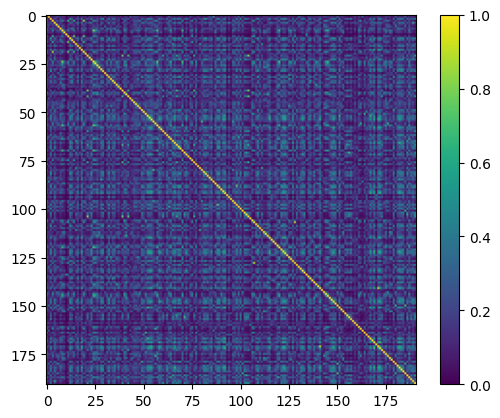

In [8]:
dos_simat.plot(colorbar=True)

Here we see that most materials in this dataset have dissimilar electronic density-of-states (DOS). The maximal similarity is 1, and all diagonal elements of the matrix are 1, because they show the similarity of a material with itself.

Note that the colorbar for these matrices will be the same along this tutorial, so we show it only here.

Before we go into further analysis of the results, let's see what else we can do with these matrices.

We can also obtain a similarity matrix directly from a `MaterialsDatabase` by specifying a fingerprint type.

In [9]:
dos_simat_from_db = db.get_similarity_matrix('DOS')

2026-04-09 18:20:45,899 - materials_database_log - INFO - Fingerprints with name "DOS" exist. Reading from database.


  0%|          | 0/191 [00:00<?, ?it/s]

Because we computed the similarity matrix from the same fingerprints before, both matrices are equal:

In [10]:
dos_simat_from_db == dos_simat

True

We can also save and load a matrix. Note that the default filename is `'similarity_matrix.npy'`.

In [11]:
dos_simat.save(filepath='data')

After loading, the matrices will be the same:

In [12]:
dos_simat_from_file = SimilarityMatrix.load(filepath='data')

In [13]:
dos_simat == dos_simat_from_file

True

The comparison for equality is aware of the sorting of the matrix. If we shuffle one matrix and compare them, we will see that they are sorted the same way before comparison:

In [14]:
from random import shuffle

In [15]:
shuffled_mids = dos_simat.mids
shuffle(shuffled_mids)

In [16]:
dos_simat.get_sub_matrix(shuffled_mids) == dos_simat_from_db

True

We can obtain a subset of the matrix:

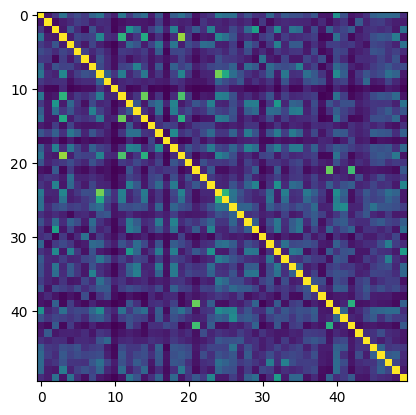

In [17]:
dos_simat.get_sub_matrix(dos_simat.mids[:50]).plot()

And also extract a non-symmetric part of the matrix:

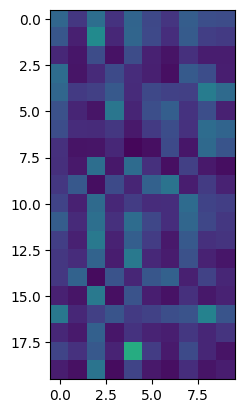

In [18]:
dos_simat.get_overlap_matrix(dos_simat.mids[:10], dos_simat.mids[-20:]).plot()

Note that the overlap matrix has a different type:

In [19]:
dos_simat.get_overlap_matrix(dos_simat.mids[:10], dos_simat.mids[-20:])

OverlapSimilarityMatrix(DOS, DOS, (20, 10))

We can extract rows of the matrix by index:

In [20]:
import matplotlib.pyplot as plt

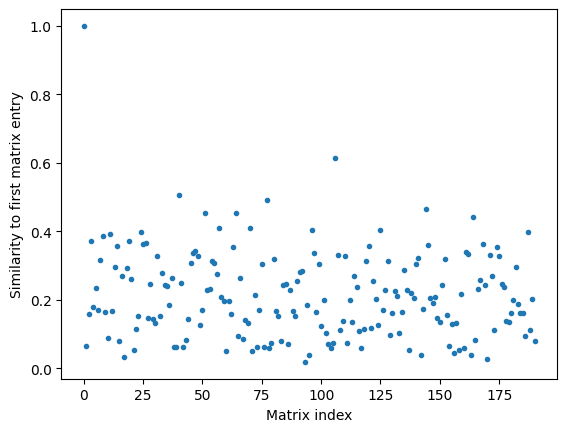

In [21]:
plt.plot(dos_simat[0], '.')
plt.xlabel("Matrix index")
plt.ylabel("Similarity to first matrix entry")
plt.show()

or by using the `mid`:

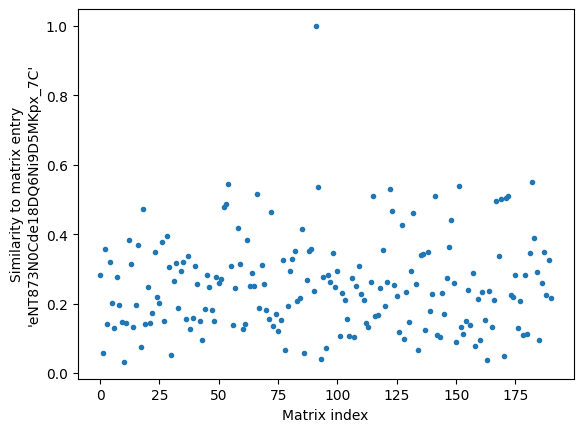

In [22]:
plt.plot(dos_simat['eNT873N0Cde18DQ6Ni9D5MKpx_7C'], '.')
plt.xlabel("Matrix index")
plt.ylabel("Similarity to matrix entry\n'eNT873N0Cde18DQ6Ni9D5MKpx_7C'")
plt.show()

We can showcase the distribution of similarities in the matrix by plotting a histogram of all unique entries:

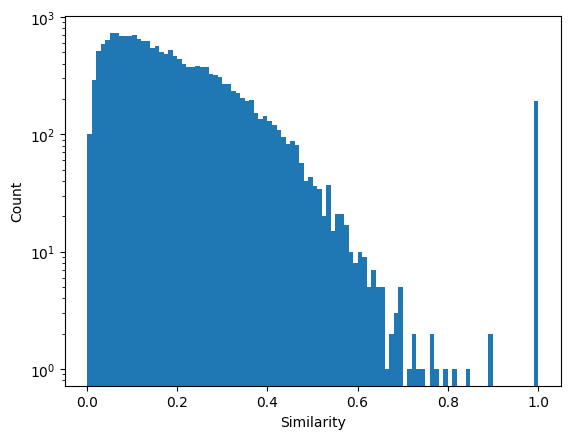

In [23]:
plt.hist(dos_simat.get_unique_entries(), bins=100)
plt.yscale('log')
plt.ylabel('Count')
plt.xlabel('Similarity')
plt.show()

Here we can see that the majority of entries in this dataset have low similarities. However, some entries with high values exist. We can use different ways of finding them.

Because the matrix contains the similarities between all data points, we can easily obtain the most similar materials for each entry:

In [24]:
most_similar_materials = dos_simat.get_k_most_similar('eNT873N0Cde18DQ6Ni9D5MKpx_7C', remove_self=False, k=5)
most_similar_materials

{'eNT873N0Cde18DQ6Ni9D5MKpx_7C': 1.0,
 'Z7yPoSxgsLVkV6T5MvhbiqL9vd6c': 0.5513439915671118,
 'CVGpxRQYzpnVv5aq8lEeOxwWuiuX': 0.5445461748393344,
 '-C9ifkl1sypqdFhloRVtLgSql5a0': 0.5373316020126603,
 'E8HK4clJ5Bm8HCEsG8w_HljiochE': 0.5358789811662285}

We can see that for this example that most similar materials are rather dissimilar, i.e., no highly similar materials exist in the dataset.

Because the database, fingerprints, and similarity matrix all use the same `mid` to identify materials, it is straightforward to inspect the DOS for these materials. Because we will look at more DOS later on, we define a function:

In [25]:
def plot_dos(db, mid):
    entry = db[mid]
    plt.plot(entry.data['dos_energies'], entry.data['dos_values'], label = entry.atoms.get_chemical_formula('reduce'))

And apply it to the most similar materials:

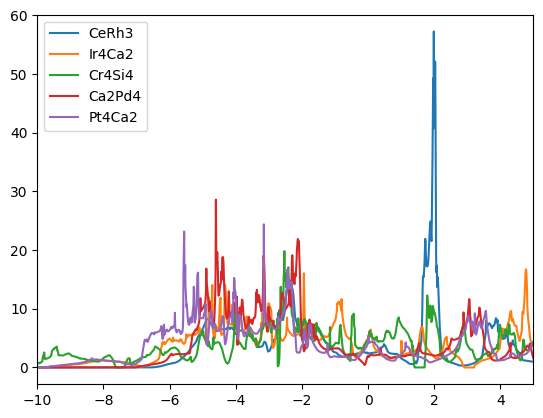

In [26]:
for mid, sim in most_similar_materials.items():
    plot_dos(db, mid)
plt.xlim(-10,5)
plt.legend()
plt.show()

Note that the first entry (CeRh3) is the reference - the material for which we searched the most similar materials. The rather low overall similarity is probably driven by the large unique feature at ~2 eV.

Manually searching for most similar materials is a great way of exploring a dataset, especially if it contains special materials that are known before the analysis. 

If no special materials are know, we can explore all sets of similar materials together by using clustering. For this MADAS provides the necessary tools.

## Cluster similarity matrices

Finding clusters in similarity matrices is slighty different to general clustering. As such, e.g., we can use only clustering methods that work with existing similarity/affinity, or distance matrices. If the similarity is computed during runtime of the algorithm on the fly, the algorithm may not be suitable.

Here, we use a "threshold clusterer", which is finding compact sets of similar entries. The algorithm is described in detail in Ref.[2]. The simplicity of this algorithm allows to use only a single parameter, the minimal similarity between two materials in order to be considered in a cluster. Furthermore, this algorithm finds compact clusters, i.e., the minimal similarity between cluster members can be controlled by tuning the threshold parameter.

To use it, we frist import the `SimilarityMatrixClusterer` class.

In [27]:
from madas.clustering import SimilarityMatrixClusterer

Then we create a `SimilarityMatrixClusterer` object, which takes a `SimilarityMatrix` as an arguments, and call the `cluster` method to find clusters. Note that the `SimilarityMatrixClusterer` has many keyword arguments that can be used to customize the clusterer (clustering method) and the arguments passed to it.

In [28]:
clus = SimilarityMatrixClusterer(dos_simat).cluster()

We can print the number of clusters:

In [29]:
print(clus.nclusters)

7


So in the whole dataset, there are only 7 clusters. When we look at the unique cluster labels:

In [30]:
print(clus.unique_labels)

[-1  0  1  2  3  4  5]


We see that label -1 is included in this number, meaning that orphans, i.e., data points that do not belong to any cluster, count as its own cluster.

We can plot the sorted similarity matrix:

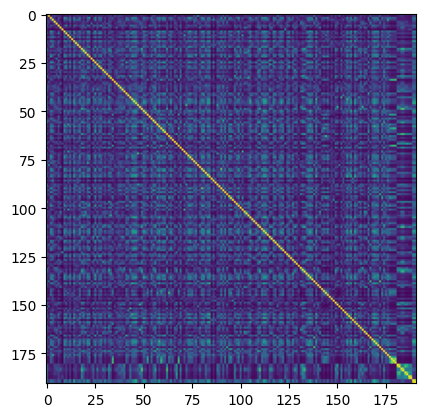

In [31]:
clus.get_sorted_similarity_matrix().plot()

Here we see that the largest part of the matrix (indices < 175) appear to be orphans, as no clear structure is visible in the matrix.

We can also plot the matrix without the orphans:

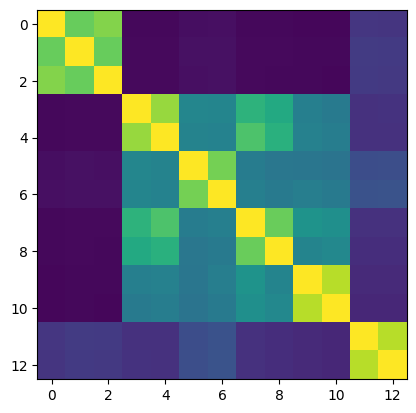

In [32]:
clus.get_sorted_similarity_matrix(remove_orphans=True).plot()

Here we can see that only 13 materials are found to be in clusters using this threshold. The remaining members of the dataset are orphans. To change this, we can lower the threshold:

In [33]:
clus.set_clusterer_params(threshold = 0.70)

and call the `cluster` method again:

In [34]:
clus = clus.cluster()

In [35]:
print(clus.nclusters)

8


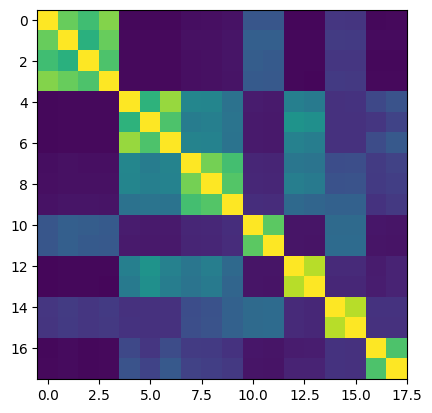

In [36]:
clus.get_sorted_similarity_matrix(remove_orphans=True).plot()

Now, one additional cluster has been found. However, the cluster assignment also has changed slightly.

We can explore the contents of these clusters by iterating over the cluster labels:

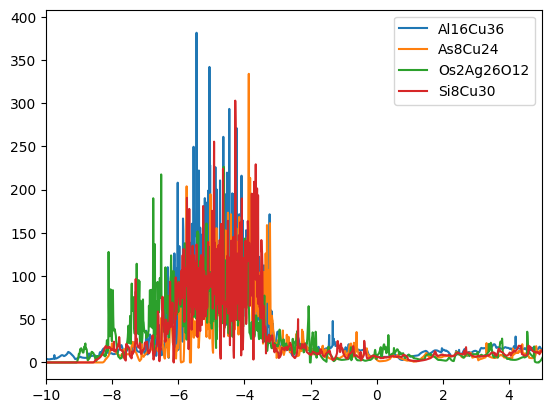

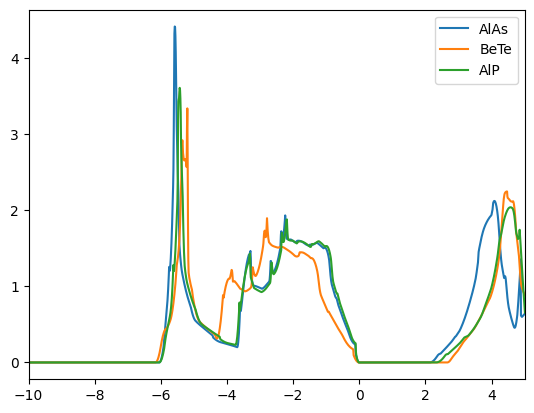

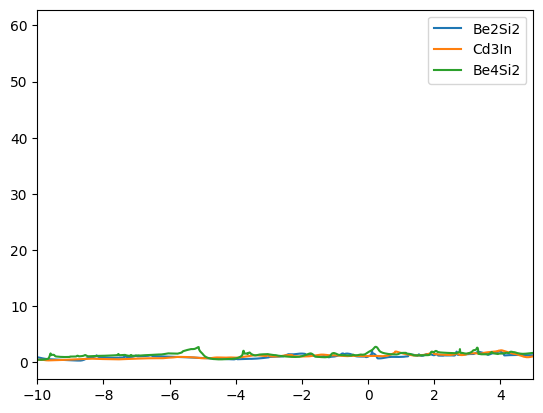

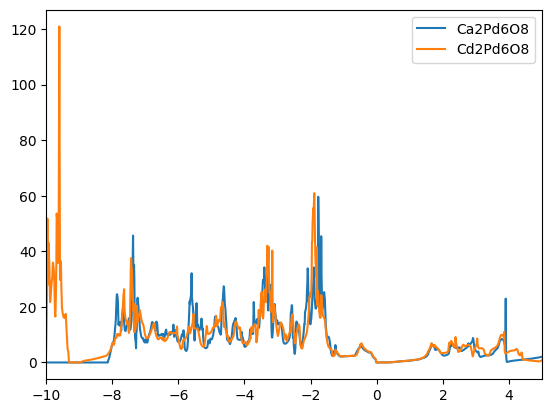

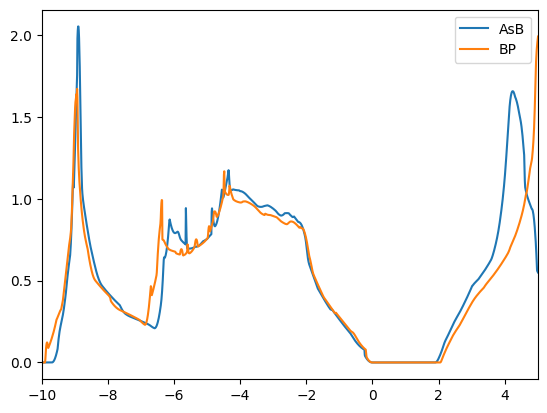

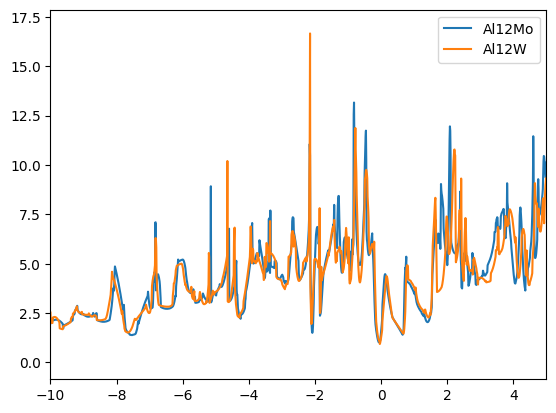

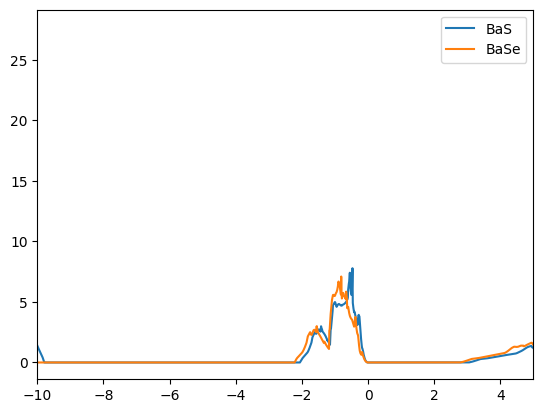

In [37]:
for label in clus.unique_labels[1:]: # start with the first entry to ignore orphans
    plt.figure()
    for mid in clus.get_mids_by_cluster_label(label):
        plot_dos(db, mid)
    plt.xlim(-10,5)
    plt.legend()

We find that the DOSs of the materials in the clusters are indeed similar. The first cluster contains mostly copper based compounds, but also a complex oxide. The second cluster finds two aluminum based binaries, where AlP and AsAl are expected to be electronically similar. However, BeTe shows a different electronic configuration. We leave the remaining analysis to the reader.

Finally, we can compare the similarities obtained with different fingeprints. To showcase this, we look into the example fingerprints that we created in the last tutorial.

## Compare different fingerprints

Because we created a custom fingerprint, the `ConcentrationVectorFingerprint` in the last tutorial, MADAS doesn't know about this class and therefore can't generate the `ConcentrationVectorFingerprint` objects. However, because they are built following the `Fingerprint` template, we can still use them from the database. We only need the similarity function from the last tutorial:

In [38]:
from madas import Fingerprint

In [39]:
def concentration_vector_similarity(fingerprint1, fingerprint2):
    number_dict1 = fingerprint1.data['concentration_dict']
    number_dict2 = fingerprint2.data['concentration_dict']
    overlap = 0
    for number in number_dict1.keys():
        try:
            overlap += min(number_dict1[number], number_dict2[number])
        except KeyError:
            pass
    return overlap

Then we can create the similarity matrix using the `MaterialsDatabase`. Note that as the `fp_type`, we use the generic `Fingerprint` class, and we use the name `'ConcentrationVectorFingerprint'` to identify which data should be loaded from the database. We also pass the similarity function as a keyword arguments, which will be passed through to the function `SimilarityMatrix.calculate`.

In [40]:
conc_simat = db.get_similarity_matrix(Fingerprint, name='ConcentrationVectorFingerprint', similarity_function = concentration_vector_similarity)

2026-04-09 18:20:55,654 - materials_database_log - INFO - Fingerprints with name "ConcentrationVectorFingerprint" exist. Reading from database.


  0%|          | 0/191 [00:00<?, ?it/s]

We can use the obtained matrix in the same way as the one computed from built-in fingerprints:

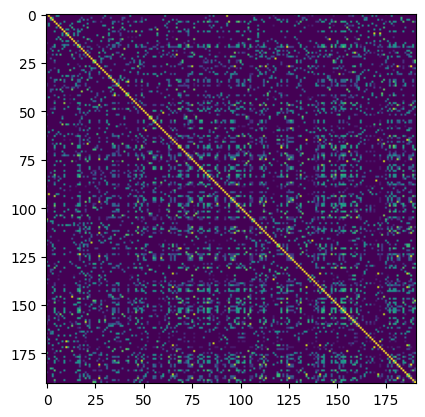

In [41]:
conc_simat.plot()

We see that the majority of entries are dissimilar using this metric, and the distribution:

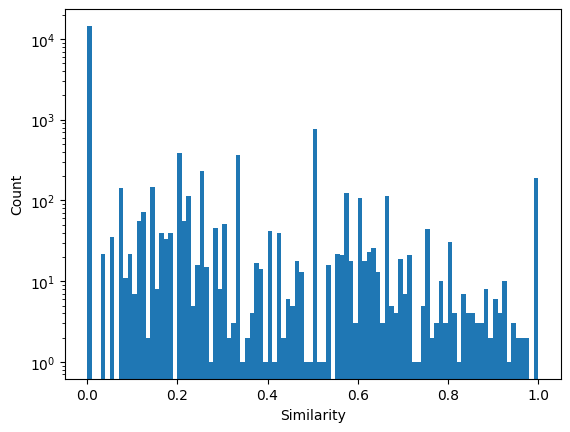

In [42]:
plt.hist(conc_simat.get_unique_entries(), bins=100)
plt.yscale('log')
plt.ylabel('Count')
plt.xlabel('Similarity')
plt.show()

Is significantly different to what we found with DOS fingerprints. We can sort the matrix based on the the DOS similarity:

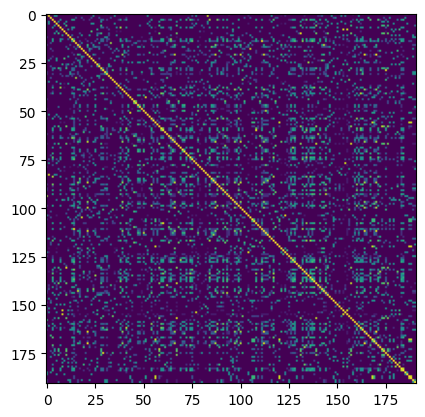

In [43]:
conc_simat.get_sub_matrix(clus.get_mids_sorted_by_cluster_labels()).plot()

We can identify a slight correlation between the two, which is better visible if we remove the orphans:

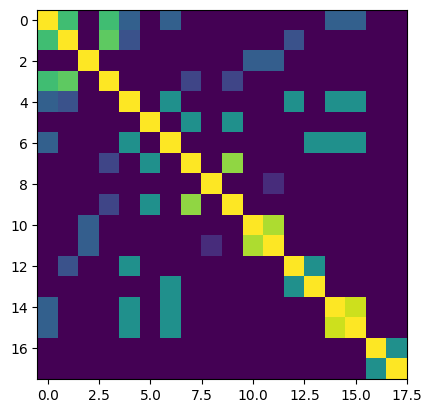

In [44]:
conc_simat.get_sub_matrix(clus.get_mids_sorted_by_cluster_labels(remove_orphans=True)).plot()

From this analysis, we can see that most of the entries with highly similar DOS also have similar elemental concentrations, meaning that at least on element is present in both compounds.

## References

**[1]** Akhil S. Nair, Lucas Foppa, and Matthias Scheffler   
_Materials Database from All-electron Hybrid Functional DFT Calculations_.  
_Sci Data_ *12*, 1518 (2025). https://doi.org/10.1038/s41597-025-05867-z

**[2]** Martin Kuban, Santiago Rigamonti, Markus Scheidgen, and Claudia Draxl:  
_Density-of-states similarity descriptor for unsupervised learning from materials data_.  
_Sci Data_ *9*, 646 (2022). https://doi.org/10.1038/s41597-022-01754-z